In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
df = sns.load_dataset('mpg')
df = df[['mpg','displacement']]
df = df.dropna()
X = df[['displacement']]
y = df['mpg']

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [10]:
lin_model = LinearRegression()
lin_model.fit(X_train,y_train)
predict_y_lin = lin_model.predict(X_test)

In [11]:
poly2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)
poly2_model = LinearRegression()
poly2_model.fit(X_train_poly2,y_train)
predict_y_poly2 = poly2_model.predict(X_test_poly2)

In [12]:
poly3 = PolynomialFeatures(degree=3)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)
poly3_model = LinearRegression()
poly3_model.fit(X_train_poly3,y_train)
predict_y_poly3 = poly3_model.predict(X_test_poly3)

In [13]:
def evaluate_model(y_true,y_pred,model_name):
    mse = mean_squared_error(y_true,y_pred)
    r2 = r2_score(y_true,y_pred)
    print(f"  {model_name}  ")
    print(f"  MSE : {mse}  ")
    print(f"  R2 score : {r2}  \n")
evaluate_model(y_test,predict_y_lin,"Linear regression")
evaluate_model(y_test,predict_y_poly2,"polynomial regression deg 2")
evaluate_model(y_test,predict_y_poly3,"polynomial regression deg 3")

  Linear regression  
  MSE : 18.102543998358946  
  R2 score : 0.6633114869465596  

  polynomial regression deg 2  
  MSE : 15.10735356108076  
  R2 score : 0.7190189176110284  

  polynomial regression deg 3  
  MSE : 14.943631793037289  
  R2 score : 0.722063972418907  



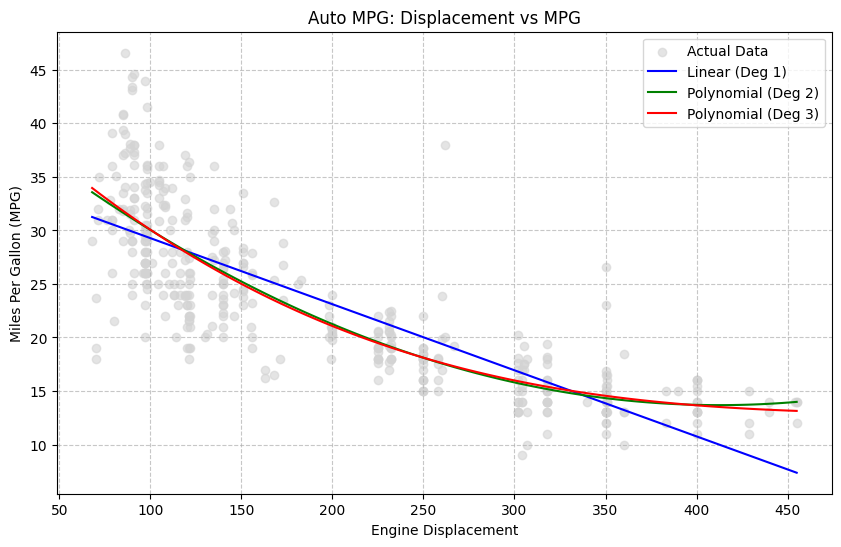

In [16]:

# Create prediction points
X_range = pd.DataFrame(
    np.linspace(X['displacement'].min(), X['displacement'].max(), 100),
    columns=['displacement']
)

# Predictions
y_range_linear = lin_model.predict(X_range)
y_range_poly2 = poly2_model.predict(poly2.transform(X_range))
y_range_poly3 = poly3_model.predict(poly3.transform(X_range))
plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='lightgray', label='Actual Data', alpha=0.6)

plt.plot(X_range['displacement'], y_range_linear, color='blue', label='Linear (Deg 1)')
plt.plot(X_range['displacement'], y_range_poly2, color='green', label='Polynomial (Deg 2)')
plt.plot(X_range['displacement'], y_range_poly3, color='red', label='Polynomial (Deg 3)')

plt.title('Auto MPG: Displacement vs MPG')
plt.xlabel('Engine Displacement')
plt.ylabel('Miles Per Gallon (MPG)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()